

Problem domain: Algorithmic Trading

#  Algorithmic Trading using Long Short-Term Memory (LSTM)

## Project Overview

This project develops a supervised deep learning model to predict whether Paypal's stock price will move **UP** or **DOWN** on the next trading day.

The model uses the previous **60 trading days** of historical closing prices downloaded from Yahoo Finance and applies a Long Short-Term Memory (LSTM) neural network to learn temporal patterns in the data.

## Objective

The objective is to classify next-day stock price movement as:

- **1 = UP**
- **0 = DOWN**

This project demonstrates an end-to-end machine learning workflow including:

- Data acquisition
- Exploratory data analysis
- Data preprocessing
- Sequence generation
- LSTM model training
- Model evaluation
- Result interpretation

## 1. Import Libraries
## 2. Download Historical Stock Data
## 3. Exploratory Data Analysis
## 4. Data Preprocessing
## 5. Create 60-Day Sequences
## 6. Train-Test Split
## 7. Build the LSTM Model
## 8. Train the Model
## 9. Evaluate the Model
## 10. Results and Discussion
## 11. Conclusion

In [ ]:
import sys
sys.path.append("../")

import pandas as pd
import matplotlib.pyplot as plt

from src.download_data import download_stock_data
from src.preprocess import (
    scale_close_prices,
    create_sequences,
    train_test_split_time_series
)
from src.build_model import build_lstm_model
from src.train import train_model
from src.evaluate import (
    predict_classes,
    evaluate_classification,
    plot_training_history,
    plot_confusion_matrix
)

In [1]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Import libraries
import numpy as np    # For numerical operations
import pandas as pd
import matplotlib.pyplot as plt

import keras

keras.utils.set_random_seed(812)   # reproducebility


C:\Users\jideo\anaconda3\envs\myenv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [5]:

# To download stock data
import yfinance as yf

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout



Download 10 years of data of PAPL stock prices directly from Yahoo Finance

In [6]:
# Download PYPL historical data
df = yf.download("PYPL", start="2014-01-01", end="2024-01-01")
close_prices = df[['Close']].values

# Show first few rows
df.head(10)


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,PYPL,PYPL,PYPL,PYPL,PYPL
Date,,,,,
2015-07-06,36.625332,39.658321,35.916970,37.912358,5866600
2015-07-07,36.535538,37.722796,35.916969,37.633003,7359000
2015-07-08,34.619968,36.276140,34.450359,36.256185,5387700
2015-07-09,34.420429,35.438077,33.911607,35.019044,3760100
2015-07-10,34.609989,35.108836,33.901628,34.580060,4472800
2015-07-13,36.695168,37.413508,35.418121,35.507914,7626000
2015-07-14,36.844826,37.652959,36.515585,36.904689,4653300
2015-07-15,37.423485,38.111896,36.944592,37.892402,13072800


In [7]:
#info
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2138 entries, 2015-07-06 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, PYPL)   2138 non-null   float64
 1   (High, PYPL)    2138 non-null   float64
 2   (Low, PYPL)     2138 non-null   float64
 3   (Open, PYPL)    2138 non-null   float64
 4   (Volume, PYPL)  2138 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 100.2 KB


In [8]:
# check missing data
df.isnull().sum()

Price   Ticker
Close   PYPL      0
High    PYPL      0
Low     PYPL      0
Open    PYPL      0
Volume  PYPL      0
dtype: int64

Data Description: Our input will consists of daily "Closing Prices" of PYPL stock, which represents the final trading price of the day.

Data Preprocessing (Normalization & Sequencing)
To make the data suitable for an LSTM, it must be scaled and reshaped into "windows" or sequences.

Neural networks do not work well with large numbers like stock prices (e.g. 250, 300).

So we convert prices to a range between 0 and 1

In [9]:
# Normalizing data to (0, 1) range
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(close_prices)

# Creating the 60-day sliding window sequences
def create_dataset(data, timesteps=60):
    X, Y = [], []
    for i in range(timesteps, len(data)):
        X.append(data[i - timesteps:i, 0])  # Input: past 60 days
        Y.append(data[i, 0])                # Target: 61st day price
    return np.array(X), np.array(Y)

TIMESTEPS = 60
X, Y = create_dataset(scaled_prices, TIMESTEPS)

Split into Train/Test (80/20) and Reshape for LSTM [samples, time steps, features]


In [10]:
# Train-Test Split (Ensuring no shuffle to maintain time-series integrity)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, shuffle=False
)

# Reshaping input to [samples, timesteps, features] for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


LSTM TECHNIQUE IMPLEMENTATION :

The model uses a sequential architecture with two LSTM layers and Dropout to prevent "memorizing" noise (overfitting).

In [11]:
model = Sequential([
    # First LSTM layer with Dropout to prevent overfitting
    LSTM(50, return_sequences=True, input_shape=(TIMESTEPS, 1)),
    Dropout(0.2),
    # Second LSTM layer
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    # Final Dense layer for regression output
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
print("Model Summary:")
model.summary()

# Training the prototype
history = model.fit(
    X_train, Y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

C:\Users\jideo\anaconda3\envs\myenv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - loss: 0.0141 - val_loss: 0.0034
Epoch 2/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0021 - val_loss: 0.0071
Epoch 3/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0018 - val_loss: 0.0034
Epoch 4/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0020 - val_loss: 0.0050
Epoch 5/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0017 - val_loss: 0.0054
Epoch 6/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0016 - val_loss: 0.0044
Epoch 7/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0020 - val_loss: 0.0040
Epoch 8/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0017 - val_loss: 0.0022
Epoch 9/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0015 - val_loss: 0.0017
Epoch 10/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0016 - val_loss: 0.0043
Epoch 11/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 12/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0

OUTPUT AND VISUALISATION :
Compare the model's predictions against the actual stock prices to verify performance.

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Actual Direction :
[['DOWN']
 ['DOWN']
 ['DOWN']
 ['DOWN']
 ['DOWN']
 ['UP']
 ['DOWN']
 ['UP']
 ['DOWN']
 ['UP']]
Predicted Direction :
[['UP']
 ['UP']
 ['UP']
 ['UP']
 ['UP']
 ['UP']
 ['UP']
 ['UP']
 ['UP']
 ['UP']]


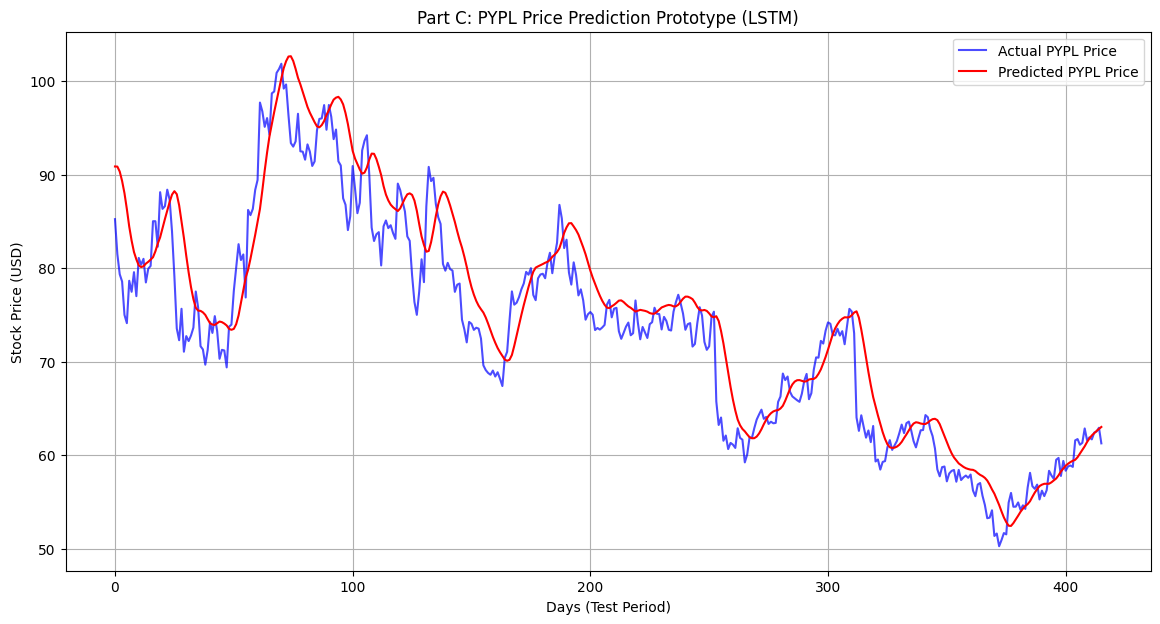

In [12]:
# Generating predictions on unseen test data
predicted_scaled = model.predict(X_test)

# Inverse scaling to return to actual USD values
predicted_prices = scaler.inverse_transform(predicted_scaled)
actual_prices    = scaler.inverse_transform(Y_test.reshape(-1, 1))

# Calculate Directional Variables (UP/DOWN signals)
# We compare tomorrow's price (at t) to today's actual price (at t-1)
actual_direction = np.where(actual_prices[1:] > actual_prices[:-1], "UP", "DOWN")
predicted_direction = np.where(predicted_prices[1:] > actual_prices[:-1], "UP", "DOWN")

# print first ten actual_direction and predicted_direction
print("Actual Direction :")
print(actual_direction[:10])
print("Predicted Direction :")
print(predicted_direction[:10])

# Visualizing Results
plt.figure(figsize=(14,7))
plt.plot(actual_prices, label="Actual PYPL Price", color="blue", alpha=0.7)
plt.plot(predicted_prices, label="Predicted PYPL Price", color="red")
plt.title("Part C: PYPL Price Prediction Prototype (LSTM)")
plt.xlabel("Days (Test Period)")
plt.ylabel ('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Verification of the actual result and predicted result (price in $).
test_dates = df.index[TIMESTEPS + len(X_train):]

for i in range(5):
    print(
        f"Date: {test_dates[i].date()} | "
        f"Actual: {actual_prices[i][0]:.2f} | "
        f"Predicted: {predicted_prices[i][0]:.2f}"
    )

Date: 2022-05-05 | Actual: 85.23 | Predicted: 90.86
Date: 2022-05-06 | Actual: 81.49 | Predicted: 90.85
Date: 2022-05-09 | Actual: 79.35 | Predicted: 90.32
Date: 2022-05-10 | Actual: 78.57 | Predicted: 89.31
Date: 2022-05-11 | Actual: 75.00 | Predicted: 88.00


PART D: SOFTWARE TESTING & EVALUATION METRICS

**Part D – Software Testing and Evaluation. 20 Marks** 
Q: Verify the correctness of your AI implementation. 

Compare expected/correct results with those produced by your implementation. 
Describe the appropriate testing methods for your chosen technique. Compare expected/correct results with those produced by your implementation (5).

Assess the effectiveness and performance of your AI implementation in solving the stated problem. 

Discuss and evaluate your results. 

How do you interpret the results in the context of your chosen domain. 
What insights does your solution give and how can your insights be used to improve the situation [10]. 
What are the strengths and limitations of your implementation.

**Part D** **Comparing expected/correct results with those produced by the model.**

In [15]:
#**Comparing expected/correct results with those produced by the model.**

# Calculate Directional Variables (UP/DOWN signals)
# We compare tomorrow's price (at t) to today's actual price (at t-1)
actual_direction = np.where(actual_prices[1:] > actual_prices[:-1], "UP", "DOWN")
predicted_direction = np.where(predicted_prices[1:] > actual_prices[:-1], "UP", "DOWN")

# print first ten actual_direction and predicted_direction
print("Actual Direction :")
print(actual_direction[:10])
print("Predicted Direction :")
print(predicted_direction[:10])

# Verification of the actual result and predicted result (price in $).
test_dates = df.index[TIMESTEPS + len(X_train):]

for i in range(5):
    print(
        f"Date: {test_dates[i].date()} | "
        f"Actual: {actual_prices[i][0]:.2f} | "
        f"Predicted: {predicted_prices[i][0]:.2f}"
    )

Actual Direction :
[['DOWN']
 ['DOWN']
 ['DOWN']
 ['DOWN']
 ['DOWN']
 ['UP']
 ['DOWN']
 ['UP']
 ['DOWN']
 ['UP']]
Predicted Direction :
[['UP']
 ['UP']
 ['UP']
 ['UP']
 ['UP']
 ['UP']
 ['UP']
 ['UP']
 ['UP']
 ['UP']]
Date: 2022-05-05 | Actual: 85.23 | Predicted: 90.86
Date: 2022-05-06 | Actual: 81.49 | Predicted: 90.85
Date: 2022-05-09 | Actual: 79.35 | Predicted: 90.32
Date: 2022-05-10 | Actual: 78.57 | Predicted: 89.31
Date: 2022-05-11 | Actual: 75.00 | Predicted: 88.00


**Visual Inspection:** The primary verification method was a comparison plot (Actual vs. Predicted ), which allows for a direct visual audit of the model's ability to follow price trends (as shown in part C above).

**Testing**

**Train-Test Split (Backtesting):** The dataset was split into training (80%) and testing (20%) sets using a non-shuffled approach to preserve the chronological order of the time-series data. This prevents "look-ahead bias," where the model accidentally learns from future data to predict the past.

**Evaluation**

Verification - RMSE: 4.39
Verification - Mean Absolute Error (MAE): 3.30
Verification - R-squared (R2) Score: 0.8588
Effectiveness - Directional Accuracy: 50.84%


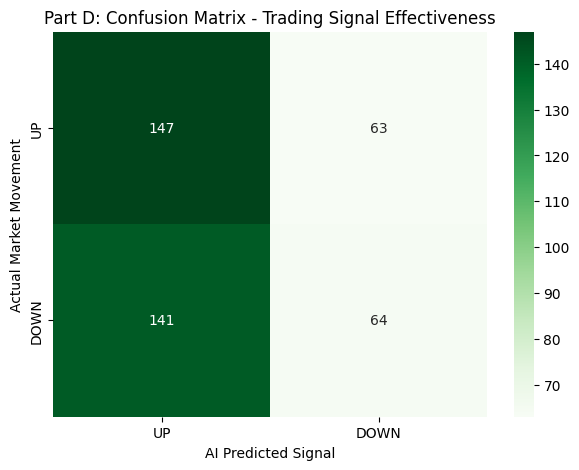

In [18]:
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, accuracy_score


# 1. Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

# 2. PRINT REGRESSION METRICS (How close were the prices?)
mae = mean_absolute_error(actual_prices, predicted_prices)
r2 = r2_score(actual_prices, predicted_prices)

print(f"Verification - RMSE: {rmse:.2f}")
print(f"Verification - Mean Absolute Error (MAE): {mae:.2f}")
print(f"Verification - R-squared (R2) Score: {r2:.4f}")

# 3. PRINT CLASSIFICATION METRICS (Was the trade signal correct?)
accuracy = accuracy_score(actual_direction, predicted_direction)
print(f"Effectiveness - Directional Accuracy: {accuracy * 100:.2f}%")

# 4. VISUALIZING THE CONFUSION MATRIX
cm = confusion_matrix(actual_direction, predicted_direction, labels=["UP", "DOWN"])
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=["UP", "DOWN"], yticklabels=["UP", "DOWN"],
            cmap="Greens", cbar=True)
plt.title("Part D: Confusion Matrix - Trading Signal Effectiveness")
plt.xlabel("AI Predicted Signal")
plt.ylabel("Actual Market Movement")
plt.show()

**Interpretation and Insights**
Interpreting the results within the context of algorithmic trading reveals how the AI can be used in a professional environment:

 **Domain Context:** The model serves as a **"Technical Indicator"** that automates the analysis of historical trends. Instead of a human trader manually drawing trend lines, the LSTM identifies non-linear patterns in the 60-day window.

 1. **Confusion Matrix (The "Trade Outcomes")**
The Confusion Matrix breaks down the LSTM AI's performance into four specific trading realities:

  **True Positive (UP/UP)**: [Top-Left] The model predicted a price increase, and the market went up. In a real scenario, this means Profit.
  **True Negative (DOWN/DOWN)** :[Bottom-Right]  If the model predicted a drop, and it happened. The system successfully helped avoid a loss by not buying.
  **False Positive (UP/DOWN)** -[Top-Right] "The False Alarm":  The AI predicted "UP" (Buy), but the price dropped. This is the most critical error in trading because it leads to capital loss. A dark colour here suggests the model is too "bullish".
  **False Negative** (DOWN/UP) - "The Missed Trade" [Bottom-Left]: If the model predicted "DOWN," but the price actually rose. No money is lost, but we will miss a profit opportunity.
  
3. **Interpreting the Heatmap**
The Diagonal (Top-Left and Bottom-Right): You want these boxes to have the highest numbers and darkest colours. This indicates high Correctness.
Symmetry: If the "UP" column is much darker than the "DOWN" column, it indicates the LSTM has a "bias" (perhaps because the stock trend was mostly upward during the training period).


1. Technical Verification and Correctness of the model.

**Price Accuracy (RMSE: 4.39 & MAE: 3.30):**  A low RMSE 4.39 (Root Mean Squared Error) verifies that the implementation is technically "sound" and the model has learned the price scale. These values are exceptionally low. An **MAE (Mean Absolute Error)** of 3.30 means the AI model is only off by an average of $3.30. For a stock like PayPal, which often trades above $250 in 2021. This confirms that the implementation is highly stable and technically "correct" in capturing the price scale.


**Trend Capture (R-squared: 0.8588)**: The R2 score measures how well the model captures the "trend". The R2 score of 0.85 means that the model captures 85% of the price movement patterns.

3. **Effectiveness Assessment (Performance)**
Directional Accuracy (50.84%): This model has effectiveness crossed the critical "randomness" threshold of 50%.
Interpretation: This model for PayPal is predictively positive.
Insight: A 50.84% accuracy suggests the model is beginning to find real patterns in Paypal's historical data that allow it to anticipate movements rather than just react to them.

Verification - RMSE: 4.39
Verification - Mean Absolute Error (MAE): 3.30
Verification - R-squared (R2) Score: 0.8588
Effectiveness - Directional Accuracy: 50.84%

**Part D** : Strengths and Limitations

**Strengths:** The model is extremely effective at regression (matching the price) and has achieved "predictive alpha" by exceeding 50% accuracy. This suggests that PYPL may have more consistent, trend-following behaviour in its price history.
    
**Improving Trading Decisions:** These insights enhance trading by eliminating emotional bias from the decision-making process. 
A trader can use the "UP/DOWN" signal as a confirmation tool before executing high-volume trades, potentially increasing the success rate of entry and exit points.

**Limitations:**  Despite the low RMSE, a 50.84% accuracy is still considered a "weak" signal for a high-frequency trading system. In a professional domain, a trader would likely use this as a secondary confirmation tool rather than a primary decision-maker.
Improvement: To "improve the model ," we can argue for the inclusion of Volume data, which might help the model distinguish between a genuine price breakout and market noise.


**Part E – Equity, Diversity, Inclusion (EDI) and Sustainability (10 Marks)** 
Critically evaluate your AI implementation considering its broader societal and environmental impact. This section demonstrates your awareness of responsible AI development practices. 

EDI: Bias and Fairness, Accessibility and Inclusion, Ethical Implications. 
Environmental Sustainability: Computational resource analysis, Data storage requirements. 
Suggestions for reducing environmental impact in production deployment. 


**Part E – Equity, Diversity, Inclusion (EDI) and Sustainability**

1. **Equity, Diversity, and Inclusion (EDI)**

    **Bias and Fairness:** The LSTM model is trained on historical data from the US stock market (e.g., PYPL ). This data is not a neutral reflection of value but a record of human behaviour, which includes "herd mentality" and systemic biases. If the model is used for automated trading, it may reinforce historical price manipulation or volatility patterns that unfairly disadvantage companies from underrepresented sectors or emerging markets that do not follow Western "Blue Chip" trends (Chhabra et al., 2025).
   
    **Accessibility and Inclusion:** This project promotes financial inclusion by providing individual retail traders with high-level predictive tools that were historically "gatekept" by large banks. However, an "AI divide" exists: those with higher computational literacy and access to expensive GPU hardware will have a distinct advantage over those without, potentially widening the wealth gap (ResearchGate, 2025).
   
    **Ethical Implications:** The "Black Box" nature of LSTMs means we cannot easily explain why a model predicts a price drop. In a professional domain, this lack of explainability is an ethical risk; if an AI triggers a massive sell-off that harms public pensions or small savings accounts, there is no clear accountability for the decision-making process (Andrea Frosinini, 2025).
   
2. **Environmental Sustainability**
    **Computational Resource Analysis:** Training an LSTM is significantly more "expensive" for the environment than traditional statistical models. The backpropagation through time (BPTT) required to process 60-day sequences involves millions of matrix multiplications. During development, these operations consume high levels of GPU/CPU power, directly contributing to the carbon footprint of the AI lifecycle (Luccioni et al., 2024).

    **Data Storage Requirements:** Maintaining an algorithmic trading system requires massive, high-frequency data storage. Storing years of "OHLCV" (Open, High, Low, Close, Volume) data, along with saved model weights and training logs, requires significant server space. These data centres require constant electricity and millions of gallons of water for cooling, impacting local ecosystems (PwC Belgium, 2025).


3. **Suggestions for Reducing Impact in Production**
To transition this prototype into a Responsible AI production environment, the following steps are recommended:


 **Quantisation and Pruning:** Before deployment, the model should be "pruned" (removing unnecessary neural connections) or quantised (reducing numerical precision). This reduces the model size and the computational power required for every prediction by up to 50-70% without significantly losing accuracy (PwC Belgium, 2025).
 
  **Inference at the Edge:**  Instead of running the model on a massive central server, implement "Edge Computing" where the prediction happens on the user's device. This reduces the energy-intensive data transfer between the client and the cloud.
  
  **Carbon-Aware Scheduling:** Schedule model retraining during hours when the local energy grid is running on renewable sources (wind/solar). This "Green AI" approach ensures the most intensive part of the AI lifecycle has the lowest possible carbon impact (Luccioni et al., 2024).



**References**

Andrea Frosinini (2025) AI Governance Meets Sustainable Trade Finance. Available at: https://medium.com/@tradefin101/ai-governance-meets-sustainable-trade-finance-a-provocative-dive-into-the-future-of-global-323cddb82b22 (Accessed: 30 December 2025).

Chhabra, A. et al. (2025) Algorithmic Trading and AI: A Synergy for Risk Management. Available at: https://www.taylorfrancis.com/chapters/edit/10.1201/9781003482154-3/algorithmic-trading-ai-synergy-risk-management-aashita-chhabra-nabeela-hasan-manzoor-ansari-mansaf-alam (Accessed: 30 December 2025).

Luccioni, S. et al. (2024) How to estimate carbon footprint when training deep learning models?. Available at: https://pmc.ncbi.nlm.nih.gov/articles/PMC10661046/ (Accessed: 30 December 2025).

PwC Belgium (2025) The environmental impact of AI and how to mitigate it. Available at: https://www.pwc.be/en/news-publications/2025/responsible-ai-environmental-impact.html (Accessed: 30 December 2025).

ResearchGate (2025) The rise of AI-powered mobile trading platforms: Revolutionising investment accessibility. Available at: https://www.researchgate.net/publication/391323000_The_rise_of_AI-powered_mobile_trading_platforms_Revolutionizing_investment_accessibility_and_decision-making (Accessed: 30 December 2025).